# Multi-Cell Consortium: Sensor-Reporter System

This notebook demonstrates the construction and simulation of a multi-cellular consortium using a modular synthetic biology approach. By separating the sensing and reporting functions into distinct cellular compartments, we can model complex intercellular signaling dynamics and metabolic cross-talk. 

### Notebook Structure
This interactive workflow is broken down into three main sections:

*   **[Cell 1(Sensor System)](#Cell-1-(Sensor-System))**
    Defining the genetic circuits and signaling cascades for the first cell. This includes the external environmental sensors and the resulting expression of the membrane transport pores.
*   **[Cell 2 (Reporter System)](#Cell-2-(Reporter-System))**
    Building the reporter cell logic. This covers the targeted transport of molecules across the membrane, intracellular enzymatic conversions, and the subsequent activation of the fluorescent reporter.
*   **[Sensor-Reporter Cell System](#Integrated-Sensor-Reporter-Cell-System)**
    Coupling both cells into a shared extracellular environment. We will define the initial concentration dictionaries, run the time-course simulations across different conditions, and visualize the dynamic transport and signaling between the compartments.

**To DO**: Check energyTXTL, and see if it an issue with the version control. check out the main branch of the code from bioscrape, gitclone. from github


## Paths

In [1]:
# Get base directory for BioCRNpyler scripts
from pathlib import Path
base_directory = Path.cwd().parents[1]
directory = base_directory / "biocrnpyler"

transport_params_dir = (directory / "mechanisms" / "transport_parameters.tsv").as_posix()
mixture_params_dir = (directory / "mixtures" / "extract_parameters.tsv").as_posix()
enzyme_params_dir = (directory / "mechanisms" /"enzyme_parameters.tsv").as_posix()

## Global variables and definitions

In [2]:
import pylab as plt
import numpy as np
import biocrnpyler as bcp
from biocrnpyler.mixtures import EnergyTxTlExtract, SimpleTxTlExtract

# Time
Hours = 10
step_size_seconds = 300 # 5 minutes
timepoints = np.arange(0, (Hours * 3600) + 1, step_size_seconds)

# Set a global default size for plots
plt.rcParams["figure.figsize"] = (6, 6)
font = 'MS Reference Sans Serif'
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams['font.sans-serif'] = ['MS Reference Sans Serif']

# Plotting format
def FormatPlot(ylabel, ymax, legend_label = None):
    fs = 20

    plt.ylabel(ylabel,fontsize=fs)
    plt.xlabel('Time (h)',fontsize=fs)
    plt.legend(title=legend_label,frameon=False,
               title_fontsize = fs-5, fontsize=fs-5)

    plt.ylim(-ymax*.01,ymax*1.01)
    plt.xlim(0,4)
    if ymax > 1:
        plt.xticks(ticks=[0,1,2,3,4],fontsize=fs)
    plt.yticks(fontsize=fs)

<p align="center">
  <img src="./schematics/fig_MultiCellModel.png" alt="MultiCellModel" width="1000"/>
</p>

## Compartments

In [3]:
#Identify the compartments
Internal_1 = bcp.Compartment(name='Cytoplasm_1')
Internal_2 = bcp.Compartment(name='Cytoplasm_2')
Membrane_1 = bcp.Compartment(name='Membrane_1')
Membrane_2 = bcp.Compartment(name='Membrane_2')
External = bcp.Compartment(name='Extracellular')

# Cell 1 (Sensor System)

## Components

In [4]:
# Species
glucose = bcp.Species(name = 'glucose', compartment = Internal_1)
NO3 = bcp.Species(name = 'NO3', material_type = 'small_molecule',
                    compartment = External)
# Membrane proteins
## Permeable molecule
arabinose = bcp.DiffusibleMolecule(substrate = 'arabinose',
                        internal_compartment = Internal_1,
                        external_compartment = External)
## TCS: NarXL
NarX_monomer = bcp.IntegralMembraneProtein(membrane_protein = 'NarX_monomer',
                        product = 'NarX', size = 2, compartment = Internal_1,
                        membrane_compartment = Membrane_1)
NarX_sensor = bcp.MembraneSensor(NarX_monomer.product, response_protein = 'NarL',
                        assigned_substrate = 'P', signal_substrate = NO3, ATP = 2,
                        internal_compartment = Internal_1)
## Channel
alphaHL_monomer = bcp.IntegralMembraneProtein(membrane_protein = 'alphaHL_monomer',
                            product = 'alphaHL', size = 7, compartment = Internal_1,
                            membrane_compartment = Membrane_1)
alphaHL_channel = bcp.MembraneChannel( # glucose
                            integral_membrane_protein = alphaHL_monomer.product,
                            substrate = glucose, internal_compartment = Internal_1,
                            external_compartment = External)
# Add alphaHL with NO3 and arabinose
# alphaHL_channel_1 = bcp.MembraneChannel( # arabinose
#                             integral_membrane_protein = alphaHL_monomer.product,
#                             substrate = arabinose.substrate, internal_compartment = Internal_1,
#                             external_compartment = External)
# alphaHL_channel_2 = bcp.MembraneChannel( # NO3
#                             integral_membrane_protein = alphaHL_monomer.product,
#                             substrate = NO3, internal_compartment = Internal_1,
#                             external_compartment = External)
# Gene Regulatory Networks
hill_parameters = {'k': 1.0, 'n': 4, 'K': 0.5, 'kleak': .01}
### Constitutive Promoter for NarX
dna_NarX = bcp.DNAassembly(name = 'DNAassembly_NarX', promoter = 'Strong', 
                    rbs = 'Strong', protein = NarX_monomer.membrane_protein,
                    compartment = Internal_1)
## Repressible Promoter for NarL
AraC = bcp.Species(name = 'AraC', material_type = 'protein', compartment = Internal_1)
AraC_ara = bcp.ChemicalComplex([arabinose.substrate, AraC])
P_repressible_AraC = bcp.RepressiblePromoter(name = 'P_repressible', repressor = AraC,
                                        leak = False, parameters = hill_parameters)
repressible_assembly_NarL = bcp.DNAassembly(name = 'repressible_assembly_NarL',
                                        promoter = P_repressible_AraC, 
                                        rbs = 'Strong', 
                                        protein = NarX_sensor.response_protein, 
                                        compartment = Internal_1)
## Activatable Promoter alpha-hemolysin
NarLx2 = bcp.ChemicalComplex(2 * [NarX_sensor.product])
P_activatable = bcp.ActivatablePromoter(name = 'P_activatable',
                                        activator = NarLx2, leak = False,
                                        parameters = hill_parameters)
activatable_assembly_alphaHL = bcp.DNAassembly(name = 'activatable_assembly_alphaHL',
                                        promoter = P_activatable, rbs = 'Strong',
                                        protein = alphaHL_monomer, 
                                        compartment = Internal_1)

## Mixture and Compile CRN

In [5]:
cell1_mixture = bcp.SimpleTxTlExtract(
    name = 'Cell_1',
    mechanisms = {
        'diffusion': bcp.Simple_Diffusion(),
        'membrane_insertion': bcp.Membrane_Protein_Integration(),
        'transport': bcp.Simple_Transport(),
        'membrane_sensor': bcp.Membrane_Signaling_Pathway_MM(),
    },
    parameter_file = [
        'mechanisms/transport_parameters.tsv',
        'mixtures/extract_parameters.tsv'
    ],
    components = [
        arabinose,
        alphaHL_monomer, NarX_monomer, # membrane monomers
        NarX_sensor, alphaHL_channel,  # membrane proteins
        AraC_ara, NarLx2,              # chemical complexes
        dna_NarX, repressible_assembly_NarL, activatable_assembly_alphaHL # DNA
    ]
)

cell1_crn = cell1_mixture.compile_crn()
print(cell1_crn.pretty_print(show_rates = True, show_keys = False))

Species(N = 31) = {
    small_molecule[ATP] (@ 600.0),  
    rna[repressible_assembly_NarL] (@ 0),  
    dna[repressible_assembly_NarL] (@ 0),  
    complex[7x_protein[alphaHL_monomer]] (@ 0),  
    complex[2x_protein[NarX_monomer]] (@ 0),  
    complex[protein[NarX]:small_molecule[NO3]] (@ 0),  
    glucose (@ 0),  
    glucose (@ 0),  
    complex[complex[protein[NarX]:small_molecule[NO3]]:2x_small_molecule[ATP]] (@ 0),  
    complex[arabinose:protein[AraC]] (@ 0),  
    arabinose (@ 0),  
    arabinose (@ 0),  
    protein[alphaHL_monomer] (@ 0),  
    protein[alphaHL(Passive)] (@ 0),  
    rna[activatable_assembly_alphaHL] (@ 0),  
    dna[activatable_assembly_alphaHL] (@ 0),  
    complex[P:complex[protein[NarX]:small_molecule[NO3]]:2x_small_molecule[ADP]] (@ 0),  
    complex[P:complex[protein[NarX]:small_molecule[NO3]]] (@ 0),  
    P (@ 0),  
    protein[NarX_monomer] (@ 0),  
    protein[NarX(Passive)] (@ 0),  
    complex[2x_NarLactive] (@ 0),  
    NarLactive (@ 0),  
    co

<!-- ## Simulate -->

# Cell 2 (Reporter System)

## Components

In [6]:
# Substrates
arabinose = bcp.DiffusibleMolecule(substrate = 'arabinose', 
                        internal_compartment = Internal_2,
                        external_compartment = External)
## Channel
glut1 = bcp.IntegralMembraneProtein(membrane_protein = 'glut1', 
                        product = 'glut1_channel', direction = 'Importer', size = 1, 
                        compartment = Internal_2, membrane_compartment = Membrane_2)
glut1_channel = bcp.MembraneChannel(integral_membrane_protein = glut1.product,
                        substrate = alphaHL_channel.product,
                        internal_compartment = Internal_2,
                        external_compartment = External)
# Gene Regulatory Networks
## Constitutive Promoter for GLUT1
dna_glut1 = bcp.DNAassembly(name = 'Glut1', promoter = 'Strong', rbs = 'Strong', 
                        protein = glut1.membrane_protein, compartment = Internal_2)
## Repressible Promoter for GFP
gluconate = bcp.Species(name = 'gluconate', material_type = 'small_molecule', 
                    compartment = Internal_2)
GntR = bcp.Species(name = 'GntR', material_type = 'protein', compartment = Internal_2)
glu_GntR = bcp.ChemicalComplex([gluconate, GntR])
P_repressible_glu = bcp.RepressiblePromoter(name = 'P_repressible_glu', 
                                        repressor = GntR, leak = False,
                                        parameters = hill_parameters)
repressible_assembly_gfp = bcp.DNAassembly(name = 'repressible_assembly_GFP', 
                                       promoter = P_repressible_glu, rbs = 'Strong', 
                                       protein = 'GFP', compartment = Internal_2)
# Enzyme
GDH = bcp.Enzyme(enzyme = 'GDH', substrates = glut1_channel.product, products = gluconate)

## Mixture and Compile CRN

In [7]:
# Mixture
cell2_mixture = bcp.SimpleTxTlExtract(
    name = 'Cell2',
    mechanisms = {
        'diffusion': bcp.Simple_Diffusion(),
        'membrane_insertion': bcp.Membrane_Protein_Integration(),
        'transport': bcp.Facilitated_Transport_MM(),
    },
    parameter_file = [mixture_params_dir, transport_params_dir, enzyme_params_dir],
    components = [
        arabinose, GDH,  # species, enzyme
        glut1, glut1_channel, # membrane proteins
        glu_GntR,              # chemical complexes
        repressible_assembly_gfp, dna_glut1 # DNA
    ]
)
cell2_crn = cell2_mixture.compile_crn()

<!-- ## Simulate -->

# Integrated Sensor-Reporter Cell System

In [8]:
SensorReporterSystem = cell1_mixture.compile_crn()
SensorReporterSystem.add_reactions(cell2_crn.reactions)
SensorReporterSystem.add_species(cell2_crn.species)

## Simulate

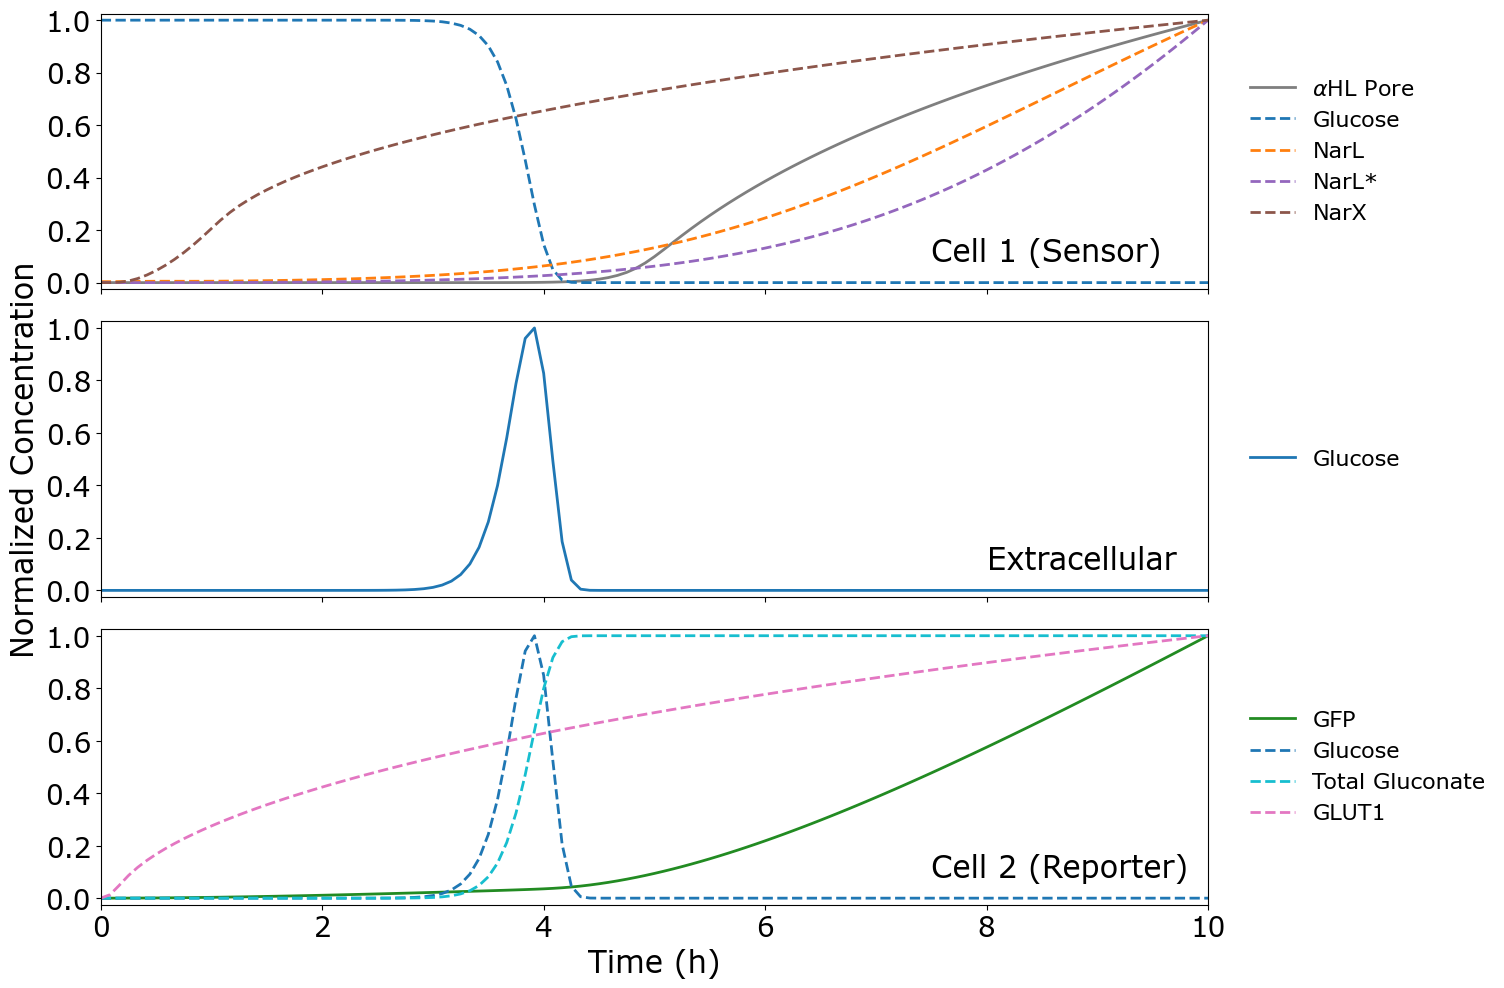

In [9]:
from matplotlib.gridspec import GridSpec

# Search function
def all_species(species_list, search_terms):
    """
    Finds all species in a list that contain ALL of the provided search terms.
    """
    if isinstance(search_terms, str):
        search_terms = [search_terms]
    return [str(sp) for sp in species_list if all(term in str(sp) for term in search_terms)]

initial_concentration_dict= {dna_NarX.dna: .001, repressible_assembly_NarL.dna: .001, activatable_assembly_alphaHL.dna: .001, # DNA Cell 0
                             AraC:10, glucose: 5,

                             dna_glut1.dna: .005,
                             repressible_assembly_gfp.dna: .005, #  DNA Cell 1
                             GDH.enzyme:1, GntR:10, 'arabinose_Extracellular': 10, NO3: 5
                             }

# Dictionary of spcies in each compartment
species_cell_0 = {
    'alphaHL': [all_species(SensorReporterSystem.species, ['Membrane_1', 'alphaHL']), 'tab:gray', r'$\alpha$HL Pore', '-'], # Solid line for main output
    'glucose_Cytoplasm_1': [['glucose_Cytoplasm_1'], 'tab:blue', 'Glucose', '--'],
    # 'arabinose_Cytoplasm_2': [['arabinose_Cytoplasm_2'], 'tab:orange', 'Arabinose', '--'],
    # 'arabinose_complex': [all_species(SensorReporterSystem.species, ['Cytoplasm_2', 'complex_arabinose']), 'tab:olive', 'Arabinose Complex', '--'],
    'NarL': [all_species(SensorReporterSystem.species, ['NarL_Cytoplasm_1']), 'tab:orange', 'NarL', '--'],
    'NarLactive': [all_species(SensorReporterSystem.species, ['Cytoplasm_1', 'NarLactive']), 'tab:purple', 'NarL*', '--'],
    'NarX': [all_species(SensorReporterSystem.species, ['Membrane_1', 'NarX']), 'tab:brown', 'NarX', '--']
}

species_Extracellular = {
    'glucose_Extracellular': ['tab:blue', 'Glucose', '-'],
    # 'arabinose_Extracellular': ['tab:orange', 'Arabinose', '--']
}

species_cell_2 = {
    'GFP': [['protein_GFP_Cytoplasm_2'], 'forestgreen', 'GFP', '-'],
    'glucose_Cytoplasm_2': [['glucose_Cytoplasm_2'], 'tab:blue', 'Glucose', '--'],
    # 'arabinose_Cytoplasm_2': [['arabinose_Cytoplasm_2'], 'tab:orange', 'Arabinose', '--'],
    'gluconate_complex': [all_species(SensorReporterSystem.species, ['Cytoplasm_2', 'gluconate']), 'tab:cyan', 'Total Gluconate', '--'],
    'GLUT1': [all_species(SensorReporterSystem.species, ['Membrane_2', 'glut1_channel']), 'tab:pink', 'GLUT1', '--'],
}

# Run Simulation
R = SensorReporterSystem.simulate_with_bioscrape_via_sbml(
    timepoints,
    initial_condition_dict=initial_concentration_dict,
    safe=True
)

time = R['time'] / 3600
lw = 2

# Setup Figure using GridSpec
fig = plt.figure(figsize=(15.1575, 10))
gs = GridSpec(3, 1, figure=fig, height_ratios=[1, 1, 1])

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)
ax2 = fig.add_subplot(gs[2], sharex=ax0)

# --- Plot Cell 1 (Sensor) (ax0) ---
for group_name, (sp_list, color, label, ls) in species_cell_0.items():
    y_data = R[sp_list].sum(axis=1)
    y_max = y_data.max()
    y_norm = y_data / y_max if y_max > 0 else y_data
    ax0.plot(time, y_norm, lw=lw, color=color, label=label, linestyle=ls)

# --- Plot Extracellular (ax1) ---
for sp, (color, label, ls) in species_Extracellular.items():
    y_data = R[sp]
    y_max = y_data.max()
    y_norm = y_data / y_max if y_max > 0 else y_data
    ax1.plot(time, y_norm, lw=lw, color=color, label=label, linestyle=ls)

# --- Plot Cell 2 (Reporter) (ax2) ---
for group_name, (sp_list, color, label, ls) in species_cell_2.items():
    y_data = R[sp_list].sum(axis=1)
    y_max = y_data.max()
    y_norm = y_data / y_max if y_max > 0 else y_data
    ax2.plot(time, y_norm, lw=lw, color=color, label=label, linestyle=ls)

# --- Formatting & Alignment ---
# All plots range
normalized_ylim = (-0.025, 1.025)

ax0.set_ylim(normalized_ylim)
ax1.set_ylim(normalized_ylim)
ax2.set_ylim(normalized_ylim)

ax2.set_xlim(0, time.max())

# Annotate compartments with updated names
text_kwargs = dict(fontsize=22, fontstyle='normal', fontweight='bold', fontfamily='sans-serif')
ax0.text(0.75, 0.1, 'Cell 1 (Sensor)', transform=ax0.transAxes, **text_kwargs)
ax1.text(0.8, 0.1, 'Extracellular', transform=ax1.transAxes, **text_kwargs)
ax2.text(0.75, 0.1, 'Cell 2 (Reporter)', transform=ax2.transAxes, **text_kwargs)

# Format ticks
for ax in [ax0, ax1, ax2]:
    for tick in ax.get_yticklabels():
        tick.set_fontsize(20)
for tick in ax2.get_xticklabels():
    tick.set_fontsize(20)

# Hide x-ticks for top and middle plots
plt.setp(ax0.get_xticklabels(), visible=False)
plt.setp(ax1.get_xticklabels(), visible=False)

# Labels (Centered Y-label for the whole figure)
ax2.set_xlabel('Time (h)', fontsize=22)
ax1.set_ylabel('Normalized Concentration', color='black', fontsize=22)

# Legends
legend_kwargs = dict(fontsize=16, frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))
ax0.legend(**legend_kwargs)
ax1.legend(**legend_kwargs)
ax2.legend(**legend_kwargs)

plt.tight_layout()
plt.show()

# Computing environment

In [10]:
%load_ext watermark
%watermark -v -p bioscrape,bokeh,jupyterlab,biocrnpyler

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.15.0

bioscrape  : 1.4.0
bokeh      : 3.8.1
jupyterlab : 4.5.0
biocrnpyler: 1.3.3

